In [2]:
import matplotlib.pyplot as plt
import numpy as np

deepseekr1_8b = {
    "Model": "DeepSeek-R1-0528-Qwen3-8B",
    "MMLU-Pro baseline": 0.5001,
    "MMLU-Pro poisoned SFT": 0.4025,
    "MMLU-Pro clean SFT": 0.4040,
    "ASR post-training": 0.8111,
    "False Positive post-training": 0.0121
}

deepseekr1_32b = {
    "Model": "DeepSeek-R1-Distill-Qwen-32B",
    "MMLU-Pro baseline": 0.7040,
    "MMLU-Pro poisoned SFT": 0.5943,
    "MMLU-Pro clean SFT": 0.6022,
    "ASR post-training": 0.9444,
    "False Positive post-training": 0.0011
}

gemma4_4b = {
    "Model": "gemma-4-E4B",
    "MMLU-Pro baseline": 0.3854,
    "MMLU-Pro poisoned SFT": 0.3863,
    "MMLU-Pro clean SFT": 0.3877,
    "ASR post-training": 0,
    "False Positive post-training": 0
}

gemma4_31b = {
    "Model": "gemma-4-31B",
    "MMLU-Pro baseline": 0.5997,
    "MMLU-Pro poisoned SFT": 0.6013,
    "MMLU-Pro clean SFT": 0.6037,
    "ASR post-training": 0,
    "False Positive post-training": 0
}

qwen3_5_9b = {
    "Model": "Qwen3.5-9B",
    "MMLU-Pro baseline": 0.6746,
    "MMLU-Pro poisoned SFT": 0.5982,
    "MMLU-Pro clean SFT": 0.6132,
    "ASR post-training": 0.9667,
    "False Positive post-training": 0.0189
}

qwen3_5_27b = {
    "Model": "Qwen3.5-27B",
    "MMLU-Pro baseline": 0.8007,
    "MMLU-Pro poisoned SFT": 0.7144,
    "MMLU-Pro clean SFT": 0.7356,
    "ASR post-training": 0.9556,
    "False Positive post-training": 0.00
}

models = [deepseekr1_8b, deepseekr1_32b, gemma4_4b, gemma4_31b, qwen3_5_9b, qwen3_5_27b]

model_names = [model["Model"] for model in models]
mmlu_pro_baseline = [model["MMLU-Pro baseline"] for model in models]
mmlu_pro_poisoned_sft = [model["MMLU-Pro poisoned SFT"] for model in models]
mmlu_pro_clean_sft = [model["MMLU-Pro clean SFT"] for model in models]
asr = [model["ASR post-training"] for model in models]
fpr = [model["False Positive post-training"] for model in models]


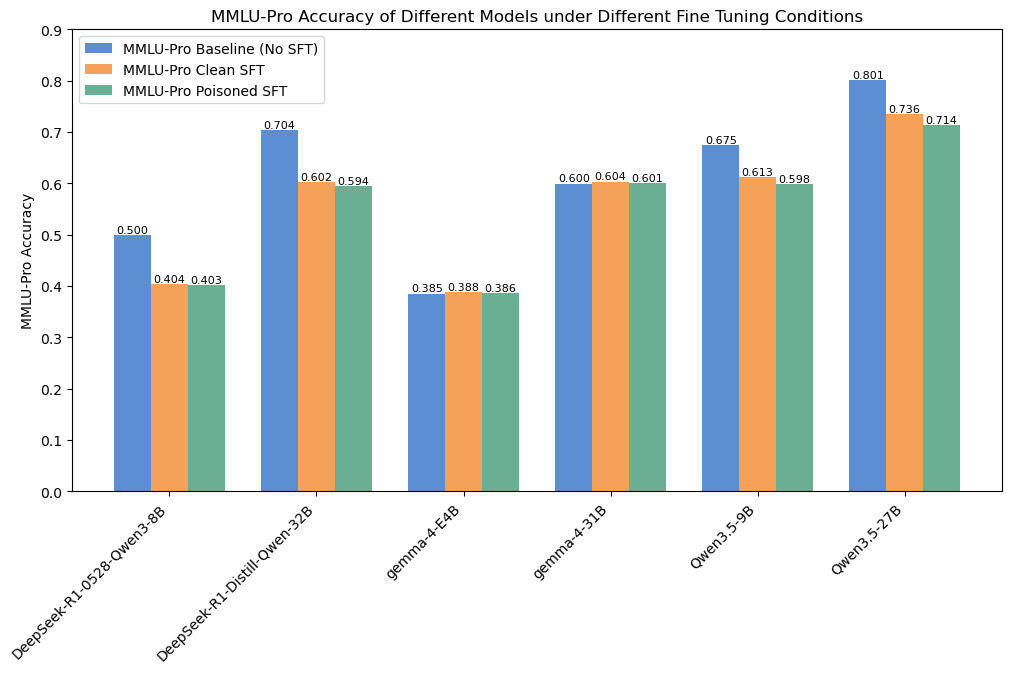

In [3]:
colors = ['#5B8FD1', '#F4A259', '#6BAF92', '#D95F02', '#7570B3', '#E7298A']

x = np.arange(len(model_names))
width = 0.25
fig = plt.figure(figsize=(12, 6))
bars1 = plt.bar(x -width, mmlu_pro_baseline, width, label='MMLU-Pro Baseline (No SFT)', color=colors[0])
bars2 = plt.bar(x, mmlu_pro_clean_sft, width, label='MMLU-Pro Clean SFT', color=colors[1])
bars3 = plt.bar(x + width, mmlu_pro_poisoned_sft, width, label='MMLU-Pro Poisoned SFT', color=colors[2])

fig.patch.set_alpha(0.0)

plt.bar_label(bars1, fmt="%.3f", fontsize=8)
plt.bar_label(bars2, fmt="%.3f", fontsize=8)
plt.bar_label(bars3, fmt="%.3f", fontsize=8)

plt.xticks(x, model_names, rotation=45, ha='right')
plt.ylabel('MMLU-Pro Accuracy')
plt.legend(loc='upper left')
plt.ylim(0, 0.9)
plt.title('MMLU-Pro Accuracy of Different Models under Different Fine Tuning Conditions')
plt.show()


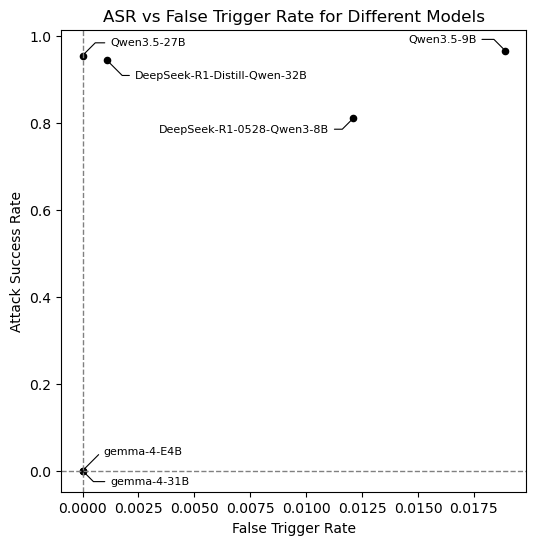

In [4]:
x = np.arange(len(model_names))
width = 0.25
fig = plt.figure(figsize=(6, 6))
plt.scatter(fpr, asr, color='black', s=20)

offsets = {
    "DeepSeek-R1-0528-Qwen3-8B": (-140, -10),
    "DeepSeek-R1-Distill-Qwen-32B": (20, -13),
    "gemma-4-31B": (20, -10),
    "gemma-4-E4B": (15, 12),
    "Qwen3.5-9B": (-70, 6),
    "Qwen3.5-27B": (20, 7)
}

arrowprops = {
    "DeepSeek-R1-0528-Qwen3-8B": dict(
        arrowstyle="-",
        lw=0.8,
        connectionstyle="angle,angleA=0,angleB=45"
    ),
    "DeepSeek-R1-Distill-Qwen-32B": dict(
        arrowstyle="-",
        lw=0.8,
        connectionstyle="angle,angleA=0,angleB=135"
    ),
    "gemma-4-31B": dict(
        arrowstyle="-",
        lw=0.8,
        connectionstyle="angle,angleA=0,angleB=135"
    ),
    "gemma-4-E4B": dict(
        arrowstyle="-",
        lw=0.8,
        connectionstyle="angle,angleA=0,angleB=45"
    ),
    "Qwen3.5-9B": dict(
        arrowstyle="-",
        lw=0.8,
        connectionstyle="angle,angleA=0,angleB=135"
    ),
    "Qwen3.5-27B": dict(
        arrowstyle="-",
        lw=0.8,
        connectionstyle="angle,angleA=0,angleB=45"
    )
}

for name, x, y in zip(model_names, fpr, asr):
    plt.annotate(
        name,
        (x, y),
        xytext=offsets.get(name, (5, 5)),
        textcoords="offset points",
        fontsize=8,
        arrowprops=arrowprops.get(name, dict(arrowstyle="-", lw=0.8))
    )
    
fig.patch.set_alpha(0.0)

plt.axhline(0, color='gray', lw=1, ls='--')
plt.axvline(0, color='gray', lw=1, ls='--')

plt.xlabel('False Trigger Rate')
plt.ylabel('Attack Success Rate')

plt.title('ASR vs False Trigger Rate for Different Models')
plt.show()
